In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Project root
BASE_DIR = Path.cwd().parent

# Cleaned dataset
DATA_FILE = (
    BASE_DIR
    / "Data"
    / "Processed"
    / "uac_cleaned.csv"
)

df = pd.read_csv(DATA_FILE)

# Convert date
df["Date"] = pd.to_datetime(df["Date"])

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (720, 9)


,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Transfer Validation Flag,Discharge Validation Flag,Negative Value Flag
0,2023-01-12,33.00,53.00,34.00,6566,436.00,False,False,False
1,2023-01-22,32.00,49.00,39.00,7122,227.00,False,False,False
2,2023-01-23,32.00,50.00,39.00,7280,181.00,False,False,False
3,2023-01-24,47.00,42.00,47.00,7433,175.00,True,False,False
4,2023-01-25,20.00,22.00,41.00,7538,180.00,True,False,False


In [3]:
print("Number of observations:", len(df))
print("Number of variables:", len(df.columns))

print("\nDate range:")
print("Start:", df["Date"].min())
print("End:", df["Date"].max())

print("\nDataset information:")
df.info()

Number of observations: 720
Number of variables: 9

Date range:
Start: 2023-01-12 00:00:00
End: 2025-12-21 00:00:00

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 9 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Date                                             720 non-null    datetime64[us]
 1   Children apprehended and placed in CBP custody*  720 non-null    float64       
 2   Children in CBP custody                          720 non-null    float64       
 3   Children transferred out of CBP custody          720 non-null    float64       
 4   Children in HHS Care                             720 non-null    int64         
 5   Children discharged from HHS Care                720 non-null    float64       
 6   Transfer Validation Flag                         720 non-null    bool          
 7  

In [4]:
df.describe().T


,count,mean,min,25%,50%,75%,max,std
Date,720,2024-07-06 05:30:00,2023-01-12 00:00:00,2023-10-16 18:00:00,2024-07-05 12:00:00,2025-03-25 06:00:00,2025-12-21 00:00:00,NaN
Children apprehended and placed in CBP custody*,720.00,93.52,0.00,12.00,99.00,147.25,333.00,72.65
Children in CBP custody,720.00,171.49,7.00,36.00,193.00,263.25,531.00,126.35
Children transferred out of CBP custody,720.00,128.67,0.00,14.00,157.00,199.25,440.00,97.32
Children in HHS Care,720.00,6061.27,1972.00,2467.75,6406.50,8010.25,11516.00,2833.07
Children discharged from HHS Care,720.00,173.41,0.00,19.75,181.00,267.00,505.00,125.70


In [5]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Missing %": (missing / len(df)) * 100
})

missing_df

,Missing Values,Missing %
Date,0,0.00
Children apprehended and placed in CBP custody*,0,0.00
Children in CBP custody,0,0.00
Children transferred out of CBP custody,0,0.00
Children in HHS Care,0,0.00
Children discharged from HHS Care,0,0.00
Transfer Validation Flag,0,0.00
Discharge Validation Flag,0,0.00
Negative Value Flag,0,0.00


In [6]:
df["Total System Load"] = (
    df["Children in CBP custody"]
    + df["Children in HHS Care"]
)

df["Net Intake Pressure"] = (
    df["Children transferred out of CBP custody"]
    - df["Children discharged from HHS Care"]
)

df["Daily Load Change"] = (
    df["Total System Load"].diff()
)

df["Daily Load Growth %"] = (
    df["Total System Load"]
    .pct_change()
    .replace([np.inf, -np.inf], np.nan)
    * 100
)

df["Discharge Offset Ratio"] = (
    df["Children discharged from HHS Care"]
    /
    df["Children transferred out of CBP custody"]
    .replace(0, np.nan)
)

df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Transfer Validation Flag,Discharge Validation Flag,Negative Value Flag,Total System Load,Net Intake Pressure,Daily Load Change,Daily Load Growth %,Discharge Offset Ratio
0,2023-01-12,33.00,53.00,34.00,6566,436.00,False,False,False,6619.00,-402.00,NaN,NaN,12.82
1,2023-01-22,32.00,49.00,39.00,7122,227.00,False,False,False,7171.00,-188.00,552.00,8.34,5.82
2,2023-01-23,32.00,50.00,39.00,7280,181.00,False,False,False,7330.00,-142.00,159.00,2.22,4.64
3,2023-01-24,47.00,42.00,47.00,7433,175.00,True,False,False,7475.00,-128.00,145.00,1.98,3.72
4,2023-01-25,20.00,22.00,41.00,7538,180.00,True,False,False,7560.00,-139.00,85.00,1.14,4.39


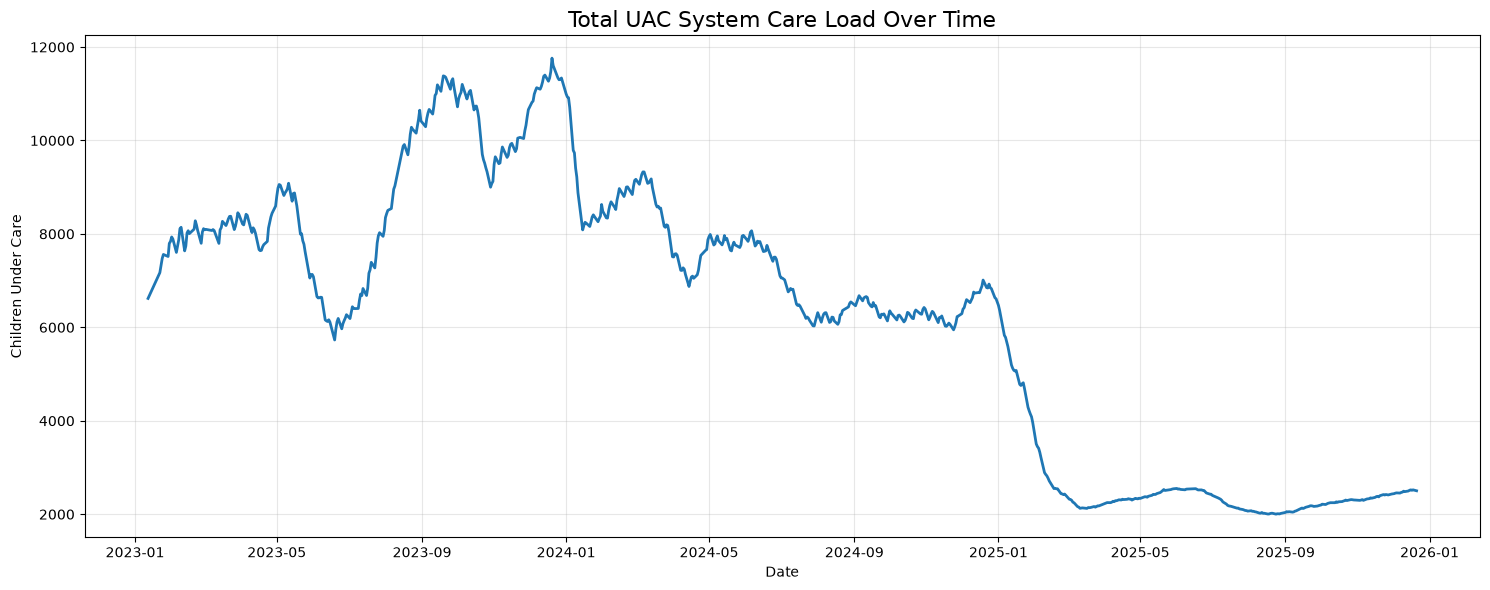

In [7]:
plt.figure(figsize=(15, 6))

plt.plot(
    df["Date"],
    df["Total System Load"],
    linewidth=2
)

plt.title(
    "Total UAC System Care Load Over Time",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Children Under Care")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

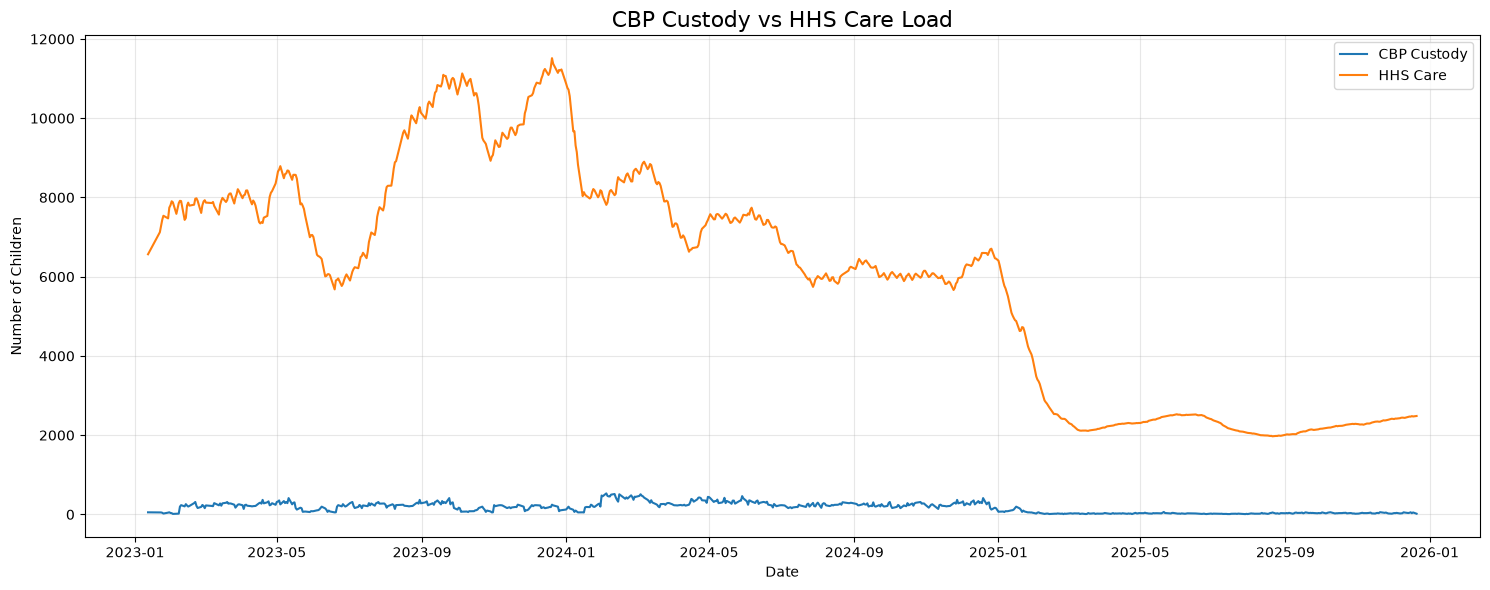

In [10]:
plt.figure(figsize=(15, 6))

plt.plot(
    df["Date"],
    df["Children in CBP custody"],
    label="CBP Custody"
)

plt.plot(
    df["Date"],
    df["Children in HHS Care"],
    label="HHS Care"
)

plt.title(
    "CBP Custody vs HHS Care Load",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Number of Children")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

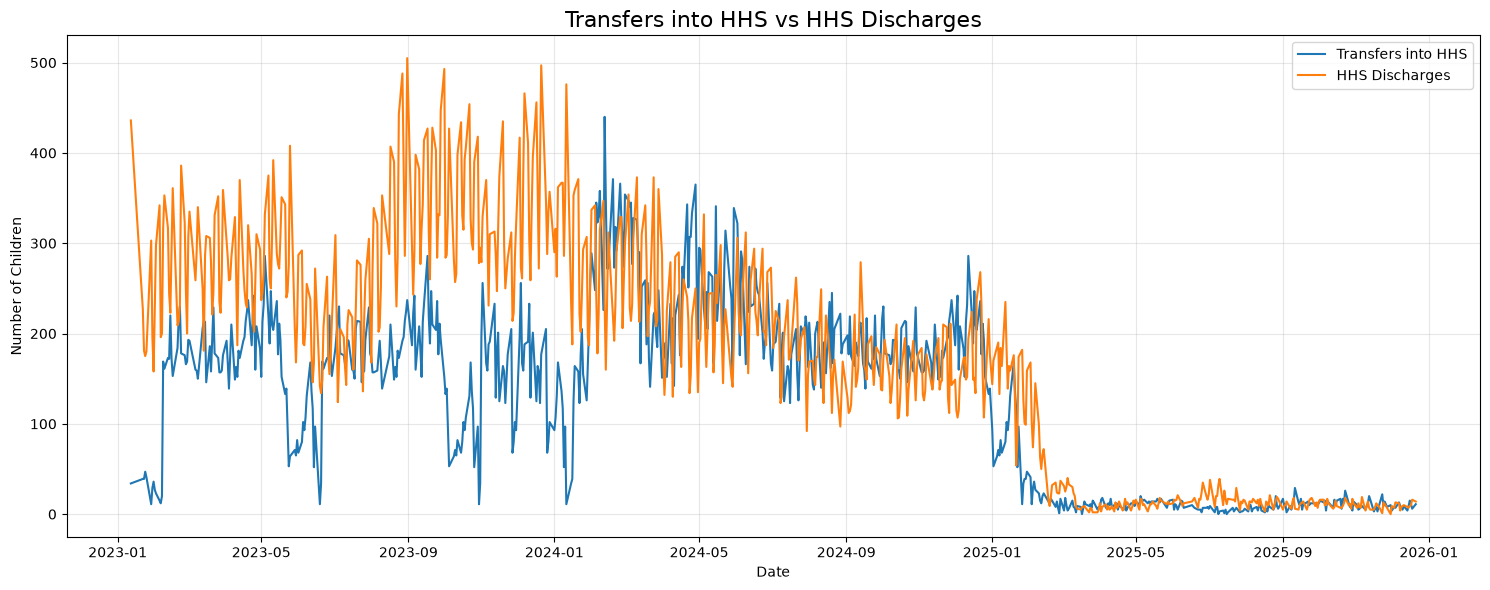

In [9]:
plt.figure(figsize=(15, 6))

plt.plot(
    df["Date"],
    df["Children transferred out of CBP custody"],
    label="Transfers into HHS"
)

plt.plot(
    df["Date"],
    df["Children discharged from HHS Care"],
    label="HHS Discharges"
)

plt.title(
    "Transfers into HHS vs HHS Discharges",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Number of Children")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

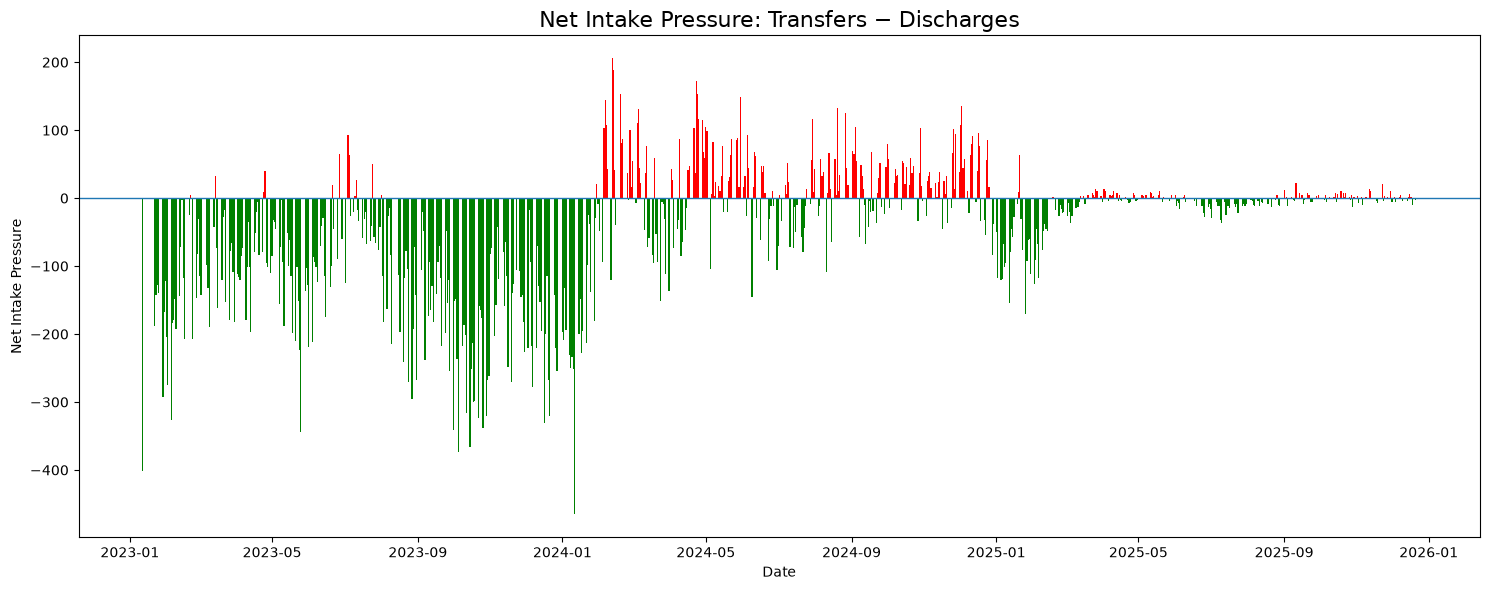

In [11]:
plt.figure(figsize=(15, 6))

colors = np.where(
    df["Net Intake Pressure"] >= 0,
    "red",
    "green"
)

plt.bar(
    df["Date"],
    df["Net Intake Pressure"],
    color=colors,
    width=1
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    "Net Intake Pressure: Transfers − Discharges",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Net Intake Pressure")

plt.tight_layout()

plt.show()

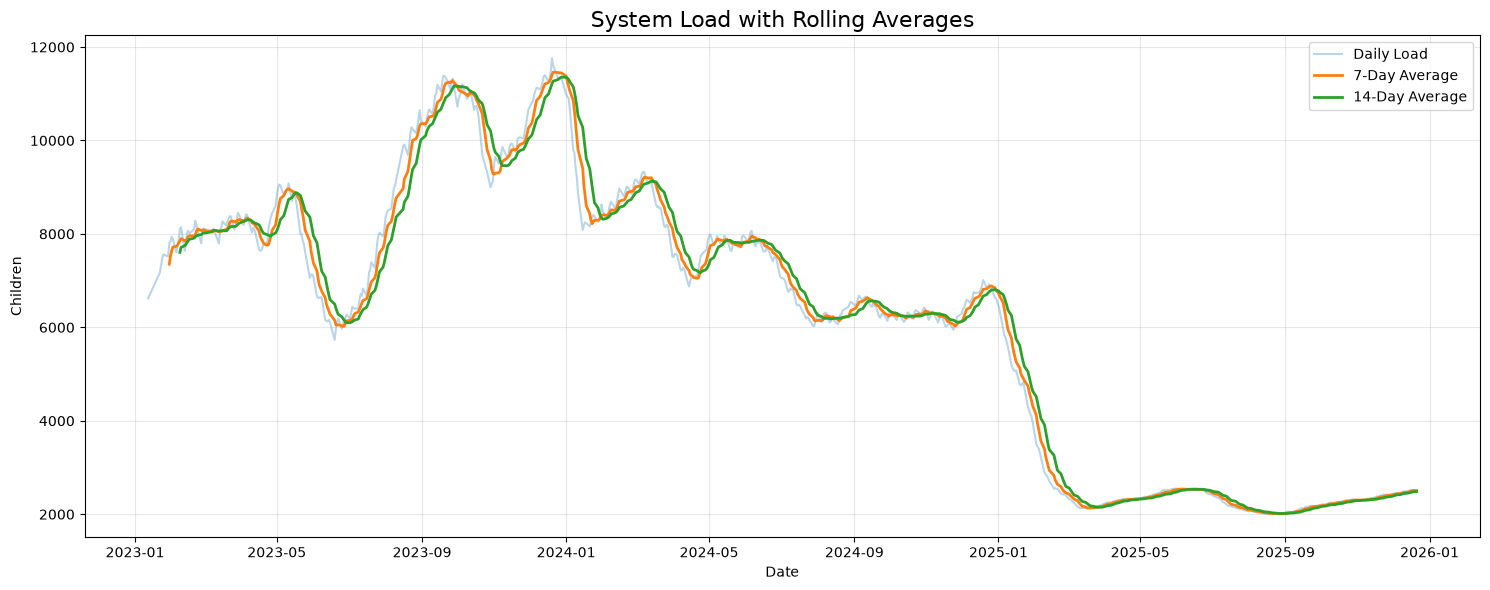

In [12]:
df["7-Day Rolling Load"] = (
    df["Total System Load"]
    .rolling(7)
    .mean()
)

df["14-Day Rolling Load"] = (
    df["Total System Load"]
    .rolling(14)
    .mean()
)

plt.figure(figsize=(15, 6))

plt.plot(
    df["Date"],
    df["Total System Load"],
    alpha=0.3,
    label="Daily Load"
)

plt.plot(
    df["Date"],
    df["7-Day Rolling Load"],
    linewidth=2,
    label="7-Day Average"
)

plt.plot(
    df["Date"],
    df["14-Day Rolling Load"],
    linewidth=2,
    label="14-Day Average"
)

plt.title(
    "System Load with Rolling Averages",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Children")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [13]:
df["Month"] = df["Date"].dt.to_period("M")

monthly = (
    df.groupby("Month")
    .agg(
        Average_System_Load=("Total System Load", "mean"),
        Average_Net_Intake=("Net Intake Pressure", "mean"),
        Total_Transfers=(
            "Children transferred out of CBP custody",
            "sum"
        ),
        Total_Discharges=(
            "Children discharged from HHS Care",
            "sum"
        )
    )
    .reset_index()
)

monthly["Month"] = monthly["Month"].astype(str)

monthly.head()

,Month,Average_System_Load,Average_Net_Intake,Total_Transfers,Total_Discharges
0,2023-01,7413.50,-197.50,276.00,1856.00
1,2023-02,7967.11,-134.00,2637.00,5183.00
2,2023-03,8190.47,-104.00,3399.00,5375.00
3,2023-04,8092.86,-81.00,3967.00,5668.00
4,2023-05,8404.09,-119.73,3622.00,6256.00


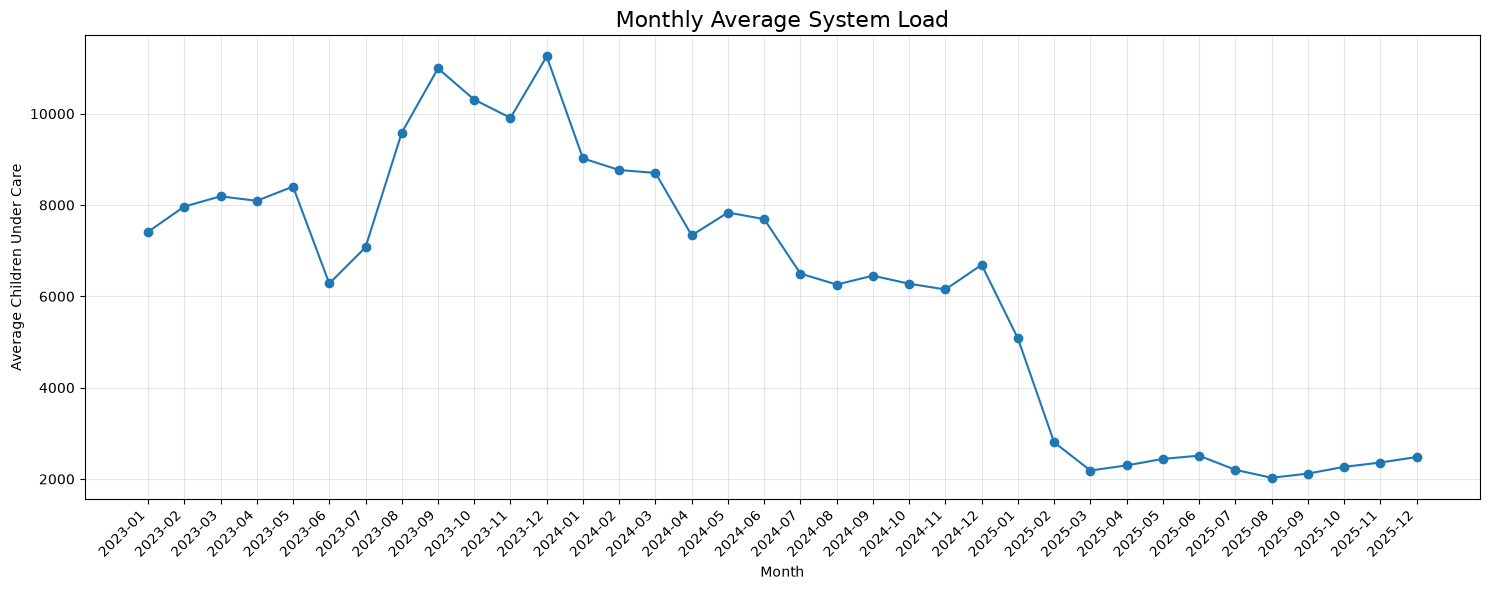

In [14]:
plt.figure(figsize=(15, 6))

plt.plot(
    monthly["Month"],
    monthly["Average_System_Load"],
    marker="o"
)

plt.title(
    "Monthly Average System Load",
    fontsize=16
)

plt.xlabel("Month")
plt.ylabel("Average Children Under Care")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

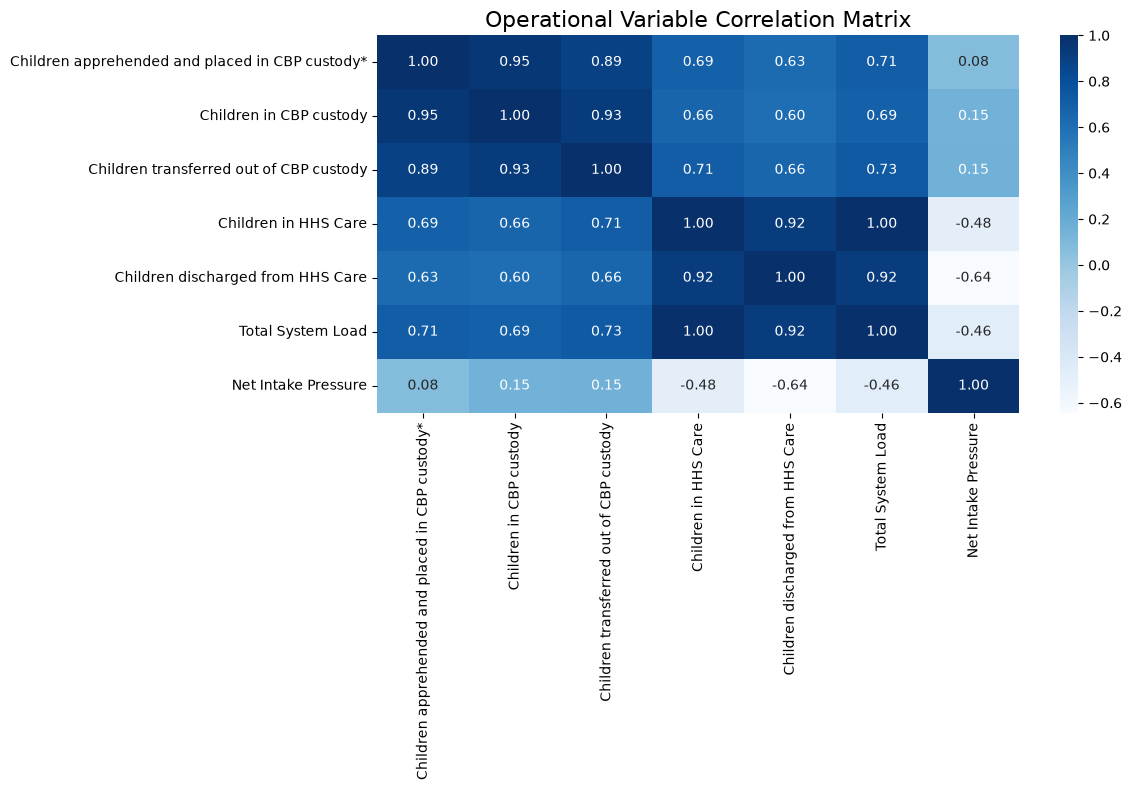

In [15]:
correlation_columns = [
    "Children apprehended and placed in CBP custody*",
    "Children in CBP custody",
    "Children transferred out of CBP custody",
    "Children in HHS Care",
    "Children discharged from HHS Care",
    "Total System Load",
    "Net Intake Pressure"
]

correlation_matrix = df[
    correlation_columns
].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title(
    "Operational Variable Correlation Matrix",
    fontsize=16
)

plt.tight_layout()

plt.show()

In [16]:
top_load_days = (
    df[
        [
            "Date",
            "Total System Load",
            "Children in CBP custody",
            "Children in HHS Care",
            "Net Intake Pressure"
        ]
    ]
    .sort_values(
        "Total System Load",
        ascending=False
    )
    .head(10)
)

top_load_days

,Date,Total System Load,Children in CBP custody,Children in HHS Care,Net Intake Pressure
224,2023-12-20,11762.00,246.00,11516,-267.00
225,2023-12-21,11603.00,228.00,11375,-320.00
223,2023-12-19,11476.00,185.00,11291,-114.00
220,2023-12-14,11399.00,157.00,11242,-195.00
161,2023-09-19,11382.00,287.00,11095,-71.00
162,2023-09-20,11374.00,310.00,11064,-117.00
219,2023-12-13,11373.00,181.00,11192,-153.00
163,2023-09-21,11352.00,285.00,11067,-218.00
226,2023-12-25,11340.00,196.00,11144,-142.00
222,2023-12-18,11337.00,188.00,11149,-200.00


In [17]:
top_pressure_days = (
    df[
        [
            "Date",
            "Net Intake Pressure",
            "Children transferred out of CBP custody",
            "Children discharged from HHS Care"
        ]
    ]
    .sort_values(
        "Net Intake Pressure",
        ascending=False
    )
    .head(10)
)

top_pressure_days

,Date,Net Intake Pressure,Children transferred out of CBP custody,Children discharged from HHS Care
259,2024-02-12,206.00,440.00,234.00
260,2024-02-13,189.00,349.00,160.00
309,2024-04-23,173.00,307.00,134.00
310,2024-04-24,153.00,307.00,154.00
263,2024-02-19,153.00,371.00,218.00
335,2024-05-30,149.00,339.00,190.00
255,2024-02-06,145.00,323.00,178.00
461,2024-12-03,135.00,242.00,107.00
391,2024-08-20,133.00,245.00,112.00
274,2024-03-05,131.00,345.00,214.00


In [18]:
relief_days = (
    df[
        [
            "Date",
            "Net Intake Pressure",
            "Children transferred out of CBP custody",
            "Children discharged from HHS Care"
        ]
    ]
    .sort_values(
        "Net Intake Pressure"
    )
    .head(10)
)

relief_days

,Date,Net Intake Pressure,Children transferred out of CBP custody,Children discharged from HHS Care
238,2024-01-11,-465.00,11.00,476.00
0,2023-01-12,-402.00,34.00,436.00
173,2023-10-05,-374.00,53.00,427.00
178,2023-10-15,-366.00,68.00,434.00
85,2023-05-25,-344.00,64.00,408.00
169,2023-10-01,-341.00,152.00,493.00
187,2023-10-26,-338.00,52.00,390.00
221,2023-12-17,-331.00,125.00,456.00
10,2023-02-05,-327.00,15.00,342.00
183,2023-10-22,-323.00,131.00,454.00


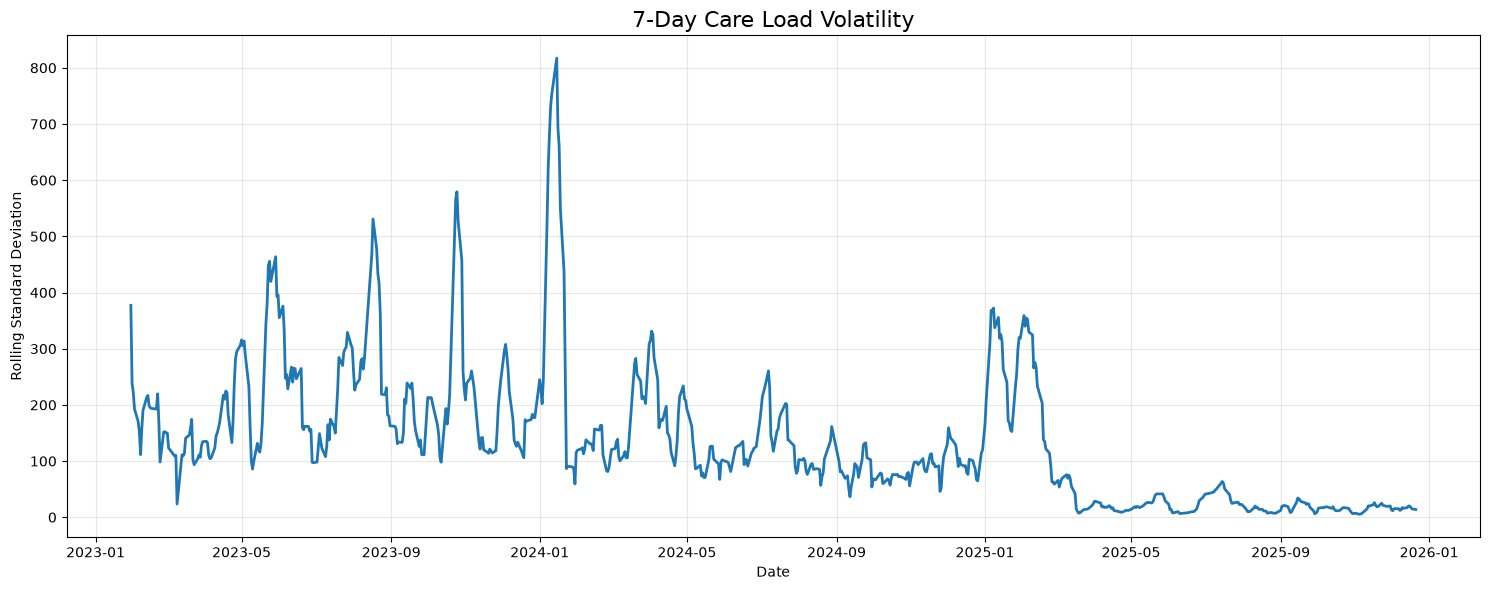

In [19]:
df["7-Day Load Volatility"] = (
    df["Total System Load"]
    .rolling(7)
    .std()
)

plt.figure(figsize=(15, 6))

plt.plot(
    df["Date"],
    df["7-Day Load Volatility"],
    linewidth=2
)

plt.title(
    "7-Day Care Load Volatility",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Rolling Standard Deviation")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()